 #  GMST over Time

## Origin of Files

In [1]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4
#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc


#        Isolating Temperature and Sea Ice:
#        for whole data
#        cdo selname,t_2m,fr_seaice PI.kepler_atm2d_merged_remapped.nc PI.kepler_t2m_sif_merged_remapped.nc


## Basic Import Statements

In [2]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm
import os
import socket
import psutil

## Loading rcParams

In [3]:
import importlib
import plot_settings
importlib.reload(plot_settings)

plot_settings.load_rcParams()

## Loading Data

In [4]:
def determine_system() -> str:
    many_cores  = os.cpu_count() > 16
    lots_of_ram = psutil.virtual_memory().total > 64 * 1024**3  # more than 64 GB
    if many_cores and lots_of_ram:
        return 'Cluster'
    else:
        return 'Jakob_Laptop'

if determine_system() == 'Jakob_Laptop':
    location_of_data = '../'
else:
    location_of_data = '/data/modeldata/ICON/icon-paleo/'

PI      = xr.open_dataset(location_of_data + 'PI.kepler/remapped_r2b4/PI.kepler_t2m_sif_merged_remapped.nc')
LIG     = xr.open_dataset(location_of_data + 'LIG.kepler/remapped_r2b4/LIG.kepler_t2m_sif_merged_remapped.nc')
LIG_ghg = xr.open_dataset(location_of_data + 'LIG.kepler.ghg/remapped_r2b4/LIG.kepler.ghg_t2m_sif_merged_remapped.nc')


## Usefull functions for deriving the GMST

In [5]:
def get_lat_weights(PI: xr.DataArray) -> xr.DataArray:
    """Create cosine-based latitude weights."""
    return np.cos(np.deg2rad(PI.lat))

def get_weighted_mean(PI: xr.DataArray) -> xr.DataArray:
    PI = PI.squeeze('height_2')
    weights = get_lat_weights(PI)
    PI_lat_weighted = PI.weighted(weights)
    
    return PI_lat_weighted.mean(dim=['lat', 'lon'])

def get_annual_mean(PI: xr.DataArray) -> xr.DataArray:
    """Resample to annual frequency and take the mean."""
    return PI.resample(time='YS').mean()

def get_annual_mean_from_raw_dataset(PI: xr.DataArray) -> xr.DataArray:
    PI_mean = get_weighted_mean(PI.t_2m)
    PI_annual = get_annual_mean(PI_mean)
    PI_annual = PI_annual[:-1] # cutoff last "year" as it is just the 01.01. of the new year, which has not been simulated
    return PI_annual

## Deriving the GMST

In [6]:
PI_annual = get_annual_mean_from_raw_dataset(PI)
LIG_annual = get_annual_mean_from_raw_dataset(LIG)
LIG_ghg_annual = get_annual_mean_from_raw_dataset(LIG_ghg)

## Deriving Mean 1770-1800

In [7]:
PI_annual_mean      =      float(PI_annual.sel(time=slice("1770", "1800")).mean(dim="time"))
LIG_annual_mean     =      float(LIG_annual.sel(time=slice("1770", "1800")).mean(dim="time"))
LIG_ghg_annual_mean =      float(LIG_ghg_annual.sel(time=slice("1770", "1800")).mean(dim="time"))

print('GMST mean for PI is:',      PI_annual_mean)
print('GMST mean for LIG is:',     LIG_annual_mean)
print('GMST mean for LIG_ghg is:', LIG_ghg_annual_mean)

print('Difference LIG-PI =',LIG_annual_mean - PI_annual_mean )
print('Difference LIG_ghg-PI =',LIG_ghg_annual_mean - PI_annual_mean )

GMST mean for PI is: 286.84772475203147
GMST mean for LIG is: 286.5332447285341
GMST mean for LIG_ghg is: 286.3653621055327
Difference LIG-PI = -0.31448002349736726
Difference LIG_ghg-PI = -0.48236264649875693


## Plotting the GMST without means

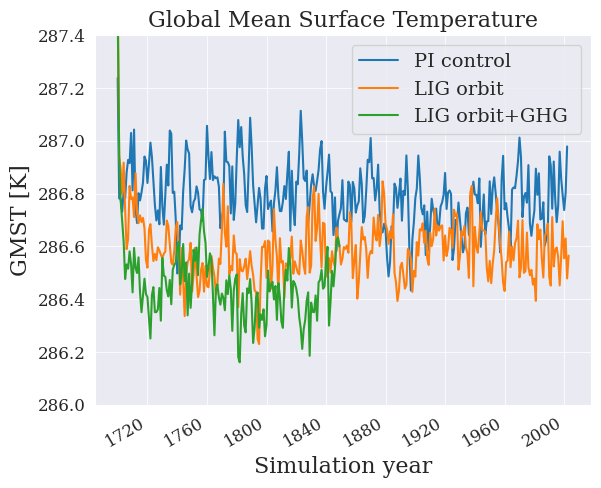

In [8]:
PI_annual.plot(label='PI control')
LIG_annual.plot(label='LIG orbit ')
LIG_ghg_annual.plot(label='LIG orbit+GHG ')
ax = plt.gca()
ax.set_title('Global Mean Surface Temperature')
ax.set_ylabel('GMST [K]')
ax.set_xlabel('Simulation year')
ax.set_ylim([286, 287.4])
ax.legend()
plt.savefig('figs/GMST.png')

## Plotting the GMST with means

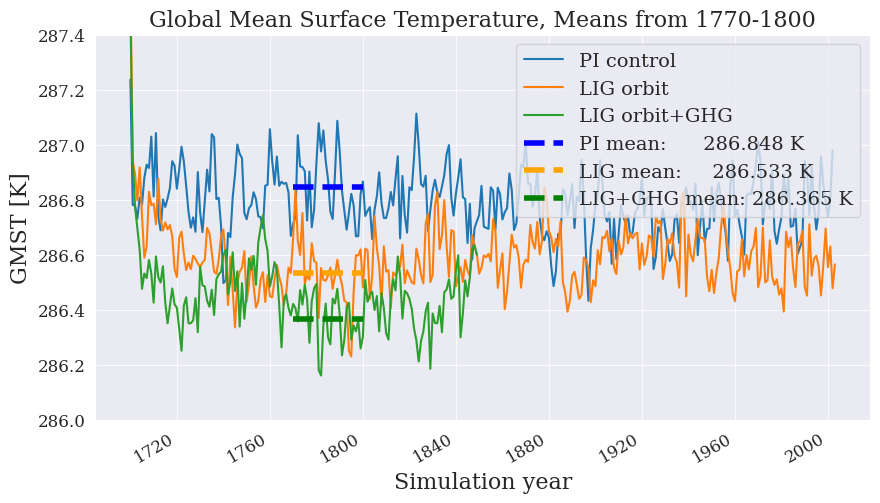

In [14]:

fig, ax = plt.subplots(figsize=(10, 5))

PI_annual.plot(      ax=ax, label='PI control')
LIG_annual.plot(     ax=ax, label='LIG orbit')
LIG_ghg_annual.plot( ax=ax, label='LIG orbit+GHG')

ax.hlines(PI_annual_mean,      np.datetime64("1770"), np.datetime64("1800"), color='blue',   linestyle='--', linewidth=4, label=f'PI mean:      {PI_annual_mean:.3f} K')
ax.hlines(LIG_annual_mean,     np.datetime64("1770"), np.datetime64("1800"), color='orange', linestyle='--', linewidth=4, label=f'LIG mean:     {LIG_annual_mean:.3f} K')
ax.hlines(LIG_ghg_annual_mean, np.datetime64("1770"), np.datetime64("1800"), color='green',  linestyle='--', linewidth=4, label=f'LIG+GHG mean: {LIG_ghg_annual_mean:.3f} K')
ax.set_title('Global Mean Surface Temperature, Means from 1770-1800')
ax.set_ylabel('GMST [K]')
ax.set_xlabel('Simulation year')
ax.set_ylim([286, 287.4])
ax.legend()
plt.savefig('figs/GMST_with_means.png')
